In [1]:
import os
import sys
import pickle
from pathlib import Path
sys.path.append('../src')

import numpy as np
import pandas as pd

from simulations import DataGeneratorBasic, DataGeneratorStratified

from plotnine import *
import patchworklib as pw

theme_set(theme_bw())

args = {}
args['cwd'] = Path.cwd()
args['root'] = args['cwd'].parent
args['data_dir'] = args['root'] / 'data'

np.random.seed(0)

<Figure size 100x100 with 0 Axes>

In [2]:
data_path = os.path.join(args['data_dir'], 'germany-population-2011.csv')
df_pop = pd.read_csv(data_path)
df_pop_subset = df_pop[(df_pop['gender'] == 'Male') & (df_pop['age'] < 30)]
pop = df_pop_subset['pop'].values

In [3]:
dg_basic = DataGeneratorBasic(n=2500, A=30, pop=pop)
df_basic, df_eval = dg_basic.generate()

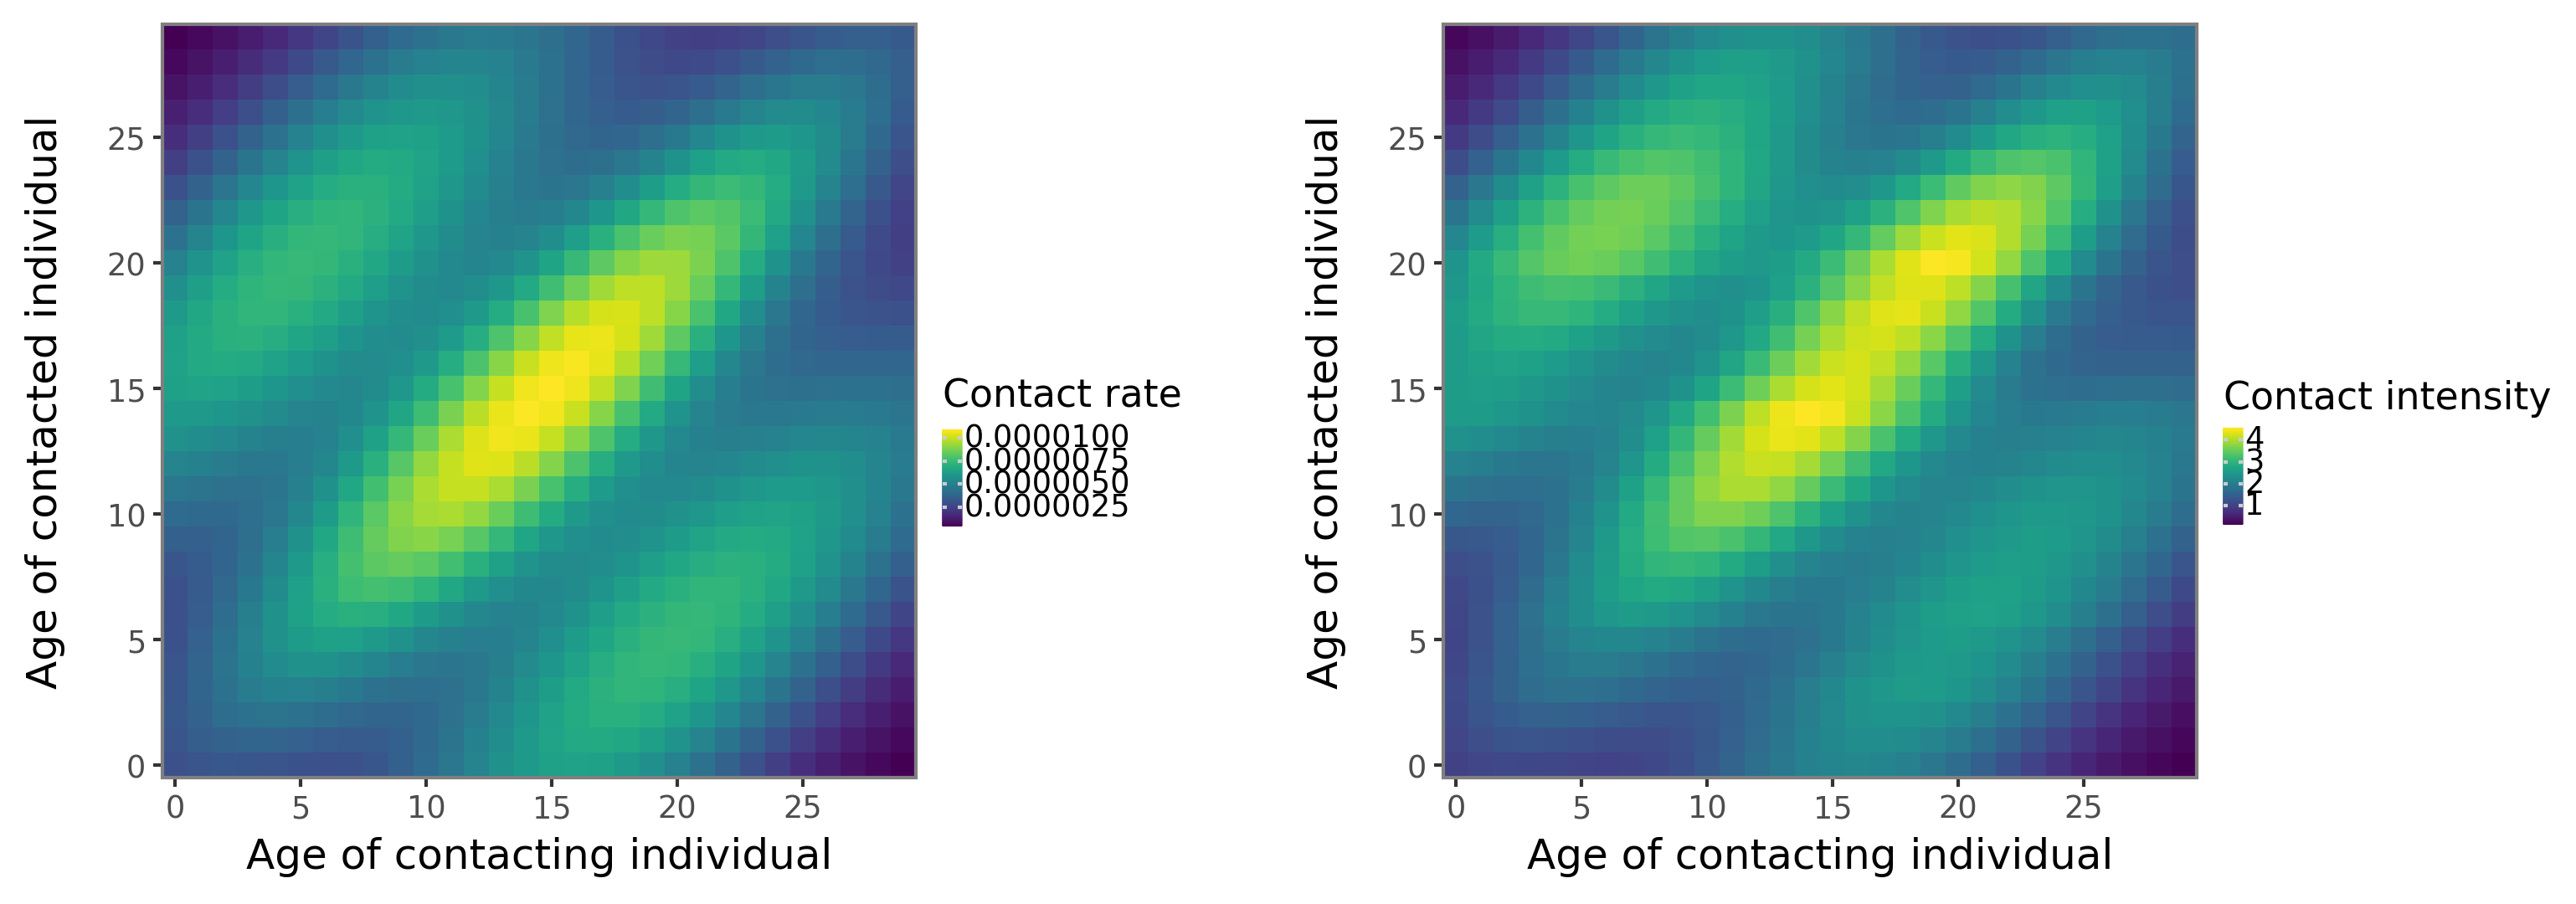

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [4]:
# Plot contact rate matrix
p_rate = (
  ggplot(df_basic, aes(x='age_part', y='age_cnt')) +
  geom_tile(aes(fill='rate')) + 
  scale_x_continuous(breaks=range(0, 30, 5), expand=(0,0)) + 
  scale_y_continuous(breaks=range(0, 30, 5), expand=(0,0)) +
  labs(x='Age of contacting individual', y='Age of contacted individual', fill='Contact rate')
)
ax1 = pw.load_ggplot(p_rate, figsize=(3,3))

# Plot contact intensity matrix
p_cint = (
  ggplot(df_basic, aes(x='age_part', y='age_cnt')) +
  geom_tile(aes(fill='cint')) + 
  scale_x_continuous(breaks=range(0, 30, 5), expand=(0,0)) + 
  scale_y_continuous(breaks=range(0, 30, 5), expand=(0,0)) +
  labs(x='Age of contacting individual', y='Age of contacted individual', fill='Contact intensity')
)
ax2 = pw.load_ggplot(p_cint, figsize=(3,3))

(ax1|ax2)

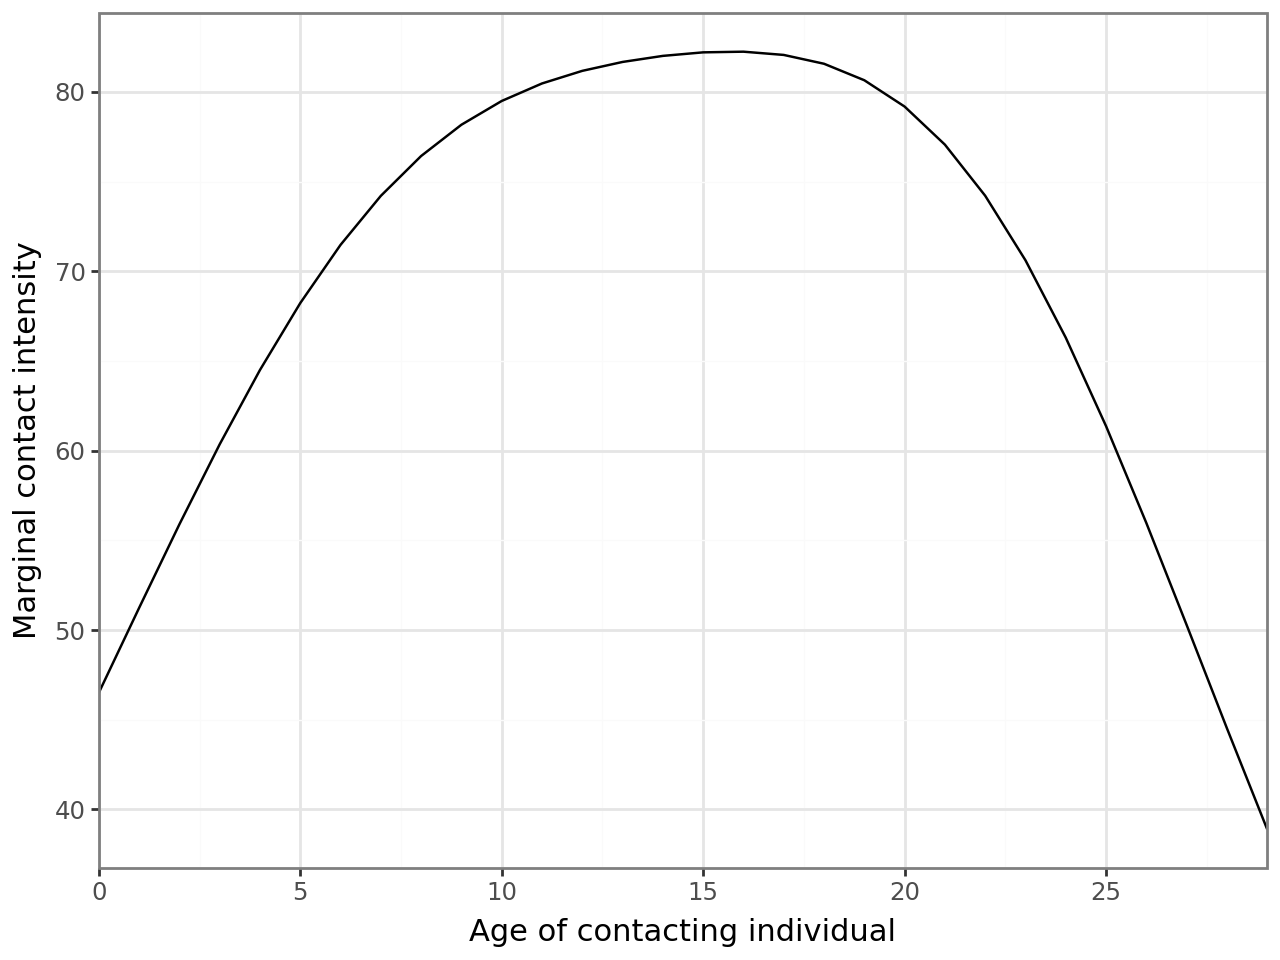

In [5]:
df_cint_margin = df_basic.groupby('age_part')['cint'].sum().reset_index()
(
  ggplot(df_cint_margin, aes(x='age_part', y='cint')) +
  geom_line() +
  scale_x_continuous(breaks=range(0, 30, 5), expand=(0,0)) +
  labs(x='Age of contacting individual', y='Marginal contact intensity')
)

In [6]:
# Save data
output_path = os.path.join(args['data_dir'], 'sim', 'basic.csv')
df_basic.to_csv(output_path, index=False)

In [7]:
def delta_linear(x):
  A = x.shape[1]
  a = np.arange(A)
  b = np.arange(A)
  X, Y = np.ix_(a, b)

  delta_1 = 1/2 + (X + Y)/29
  delta_2 = 3/2 - (1/2 + (X + Y)/29)/2

  rate_1 = x * delta_1
  rate_2 = x * delta_2

  return np.array([rate_1, rate_2])

In [8]:
dg_strat = DataGeneratorStratified(n=2500, A=30, pop=pop)
dg_strat.set_subgroup_rates(delta_linear)
dg_strat.set_subgroup_sample_sizes(lambda x: np.array([x, x]))
dg_strat.set_subgroup_populations(lambda x: np.array([1/3*x, 2/3*x]))

In [9]:
df_train, df_eval = dg_strat.generate()

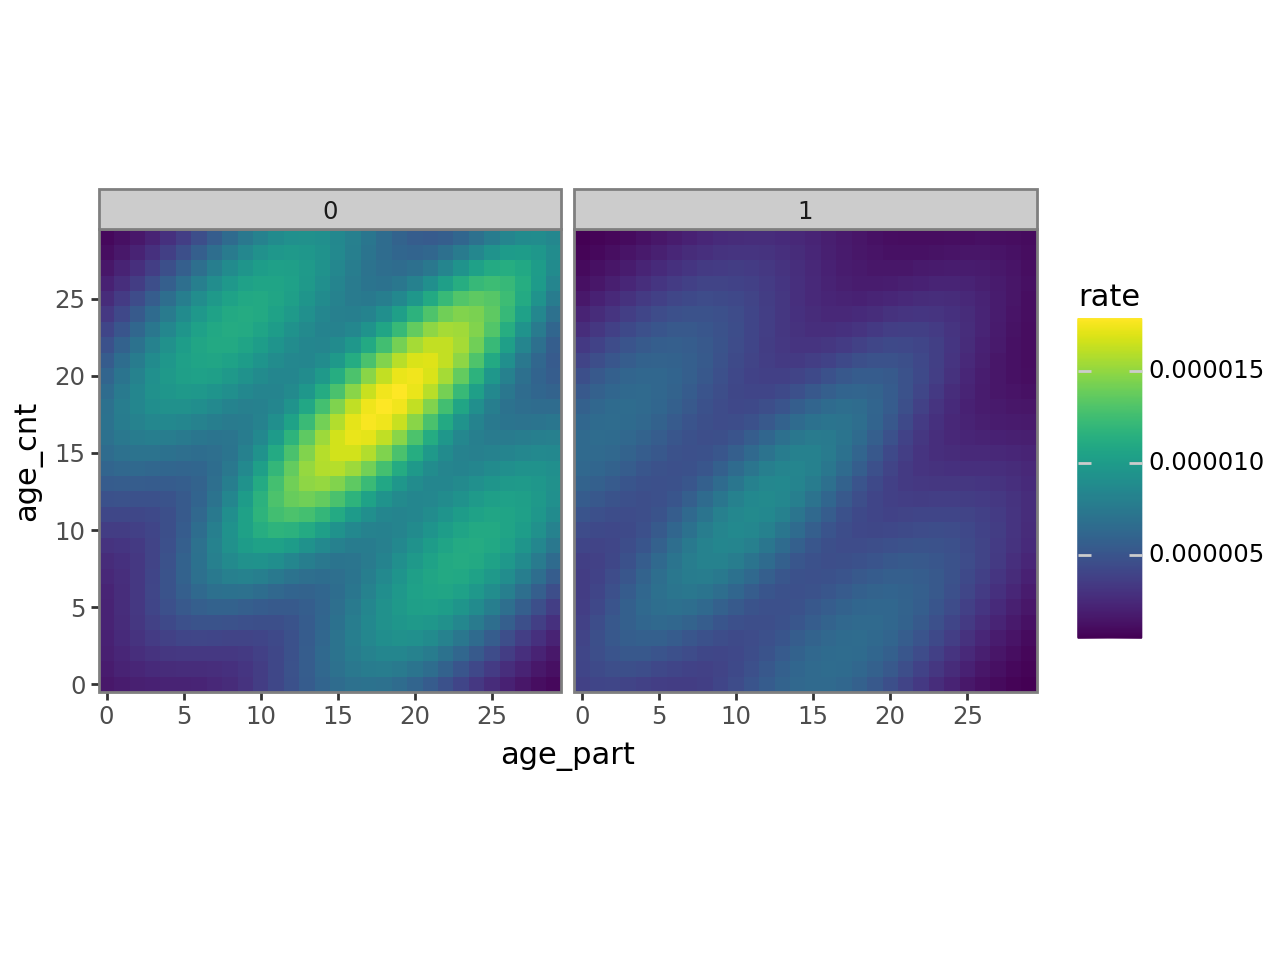

In [10]:
(
  ggplot(df_train, aes(x='age_part', y='age_cnt')) +
  geom_tile(aes(fill='rate')) +
  scale_x_continuous(breaks=range(0, 30, 5), expand=(0,0)) +
  scale_y_continuous(breaks=range(0, 30, 5), expand=(0,0)) +
  facet_wrap('subgroup') +
  theme(aspect_ratio=1)
)

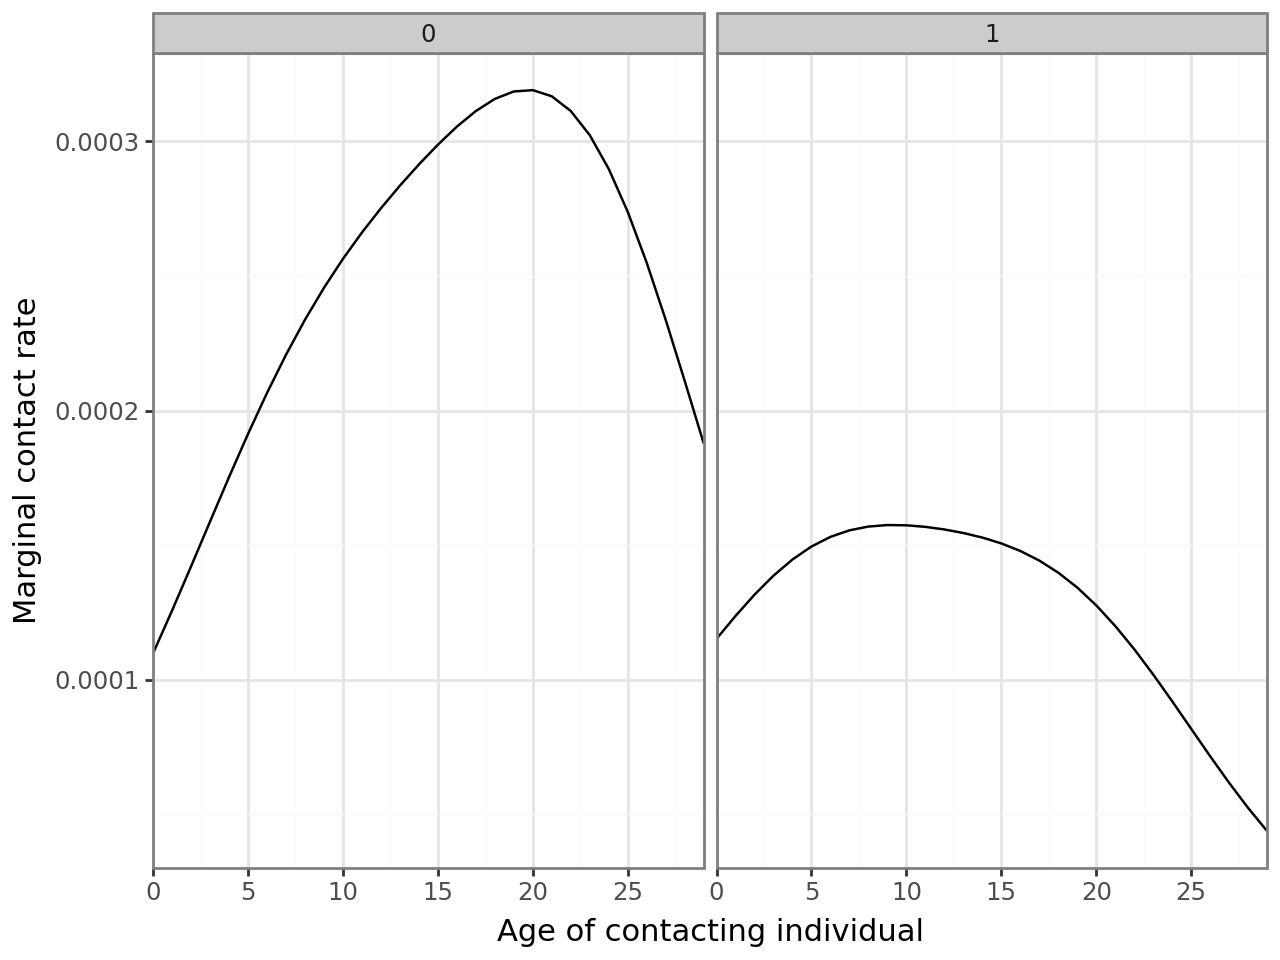

In [11]:
tmp = df_eval.groupby(['subgroup', 'age_part'])['rate'].sum().reset_index()
(
  ggplot(tmp, aes(x='age_part', y='rate')) +
  geom_line() +
  scale_x_continuous(breaks=range(0, 30, 5), expand=(0,0)) +
  facet_wrap('subgroup') +
  labs(x='Age of contacting individual', y='Marginal contact rate')
)

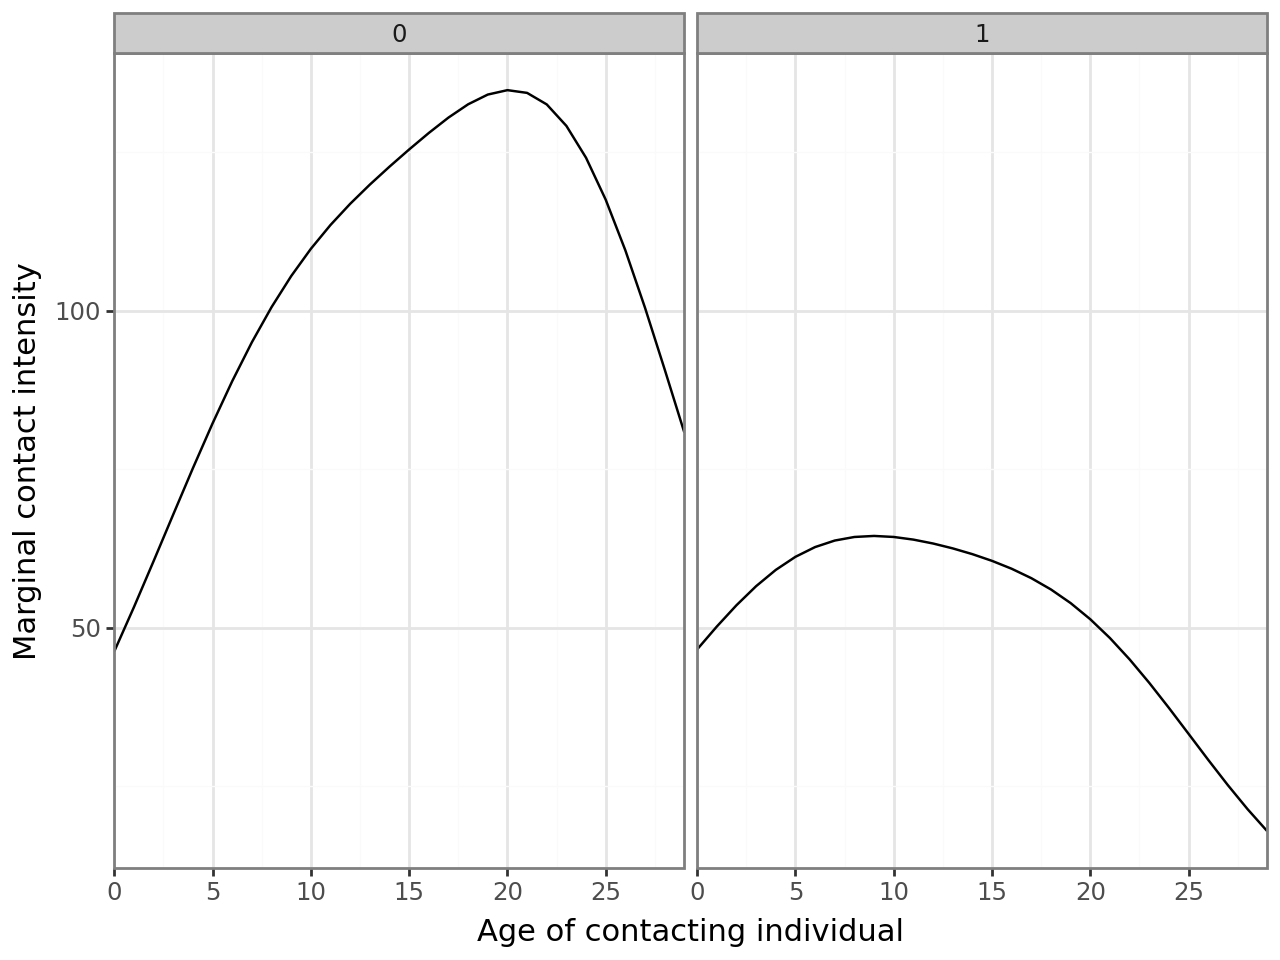

In [12]:
tmp = df_eval.groupby(['subgroup', 'age_part'])['cint'].sum().reset_index()
(
  ggplot(tmp, aes(x='age_part', y='cint')) +
  geom_line() +
  scale_x_continuous(breaks=range(0, 30, 5), expand=(0,0)) +
  facet_wrap('subgroup') +
  labs(x='Age of contacting individual', y='Marginal contact intensity')
)

In [13]:
data = {'data': dg_strat.data_train, 'pop': dg_strat.pop_subgroups}
with open(args['root']/'data'/'sim'/'train'/'stratified2.pkl', 'wb') as f:
    pickle.dump(data, f)
    
with open(args['root']/'data'/'sim'/'eval'/'stratified2.pkl', 'wb') as f:
    pickle.dump(df_eval, f)